# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama:Kadek Indri Anisa Putri
- Email:indrianisaputri14@gmail.com
- Id Dicoding:indrianisaputri

## Persiapan

### Menyiapkan library yang dibutuhkan

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

## Load Data

In [31]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [33]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [34]:
df.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [35]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [36]:
df.isnull().sum()
df.duplicated().sum()

0

## Distribusi Status

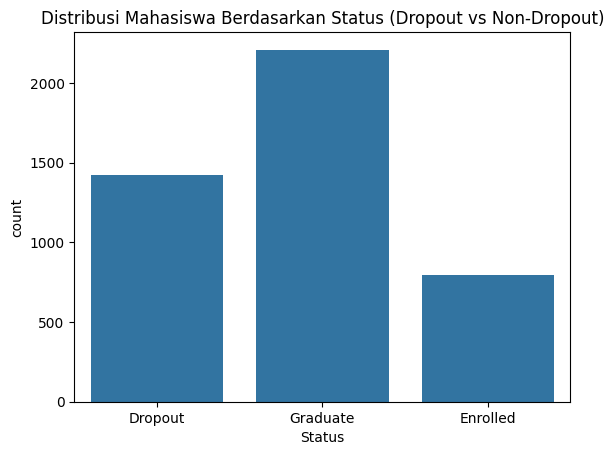

In [37]:
sns.countplot(x='Status', data=df)
plt.title('Distribusi Mahasiswa Berdasarkan Status (Dropout vs Non-Dropout)')
plt.show()

Insight:
- Mayoritas mahasiswa berada pada kategori Graduate, diikuti oleh Dropout, dan sebagian kecil masih berstatus Enrolled.
- Proporsi mahasiswa dropout mencapai sekitar 30–40% dari total populasi, menunjukkan bahwa tingkat dropout cukup signifikan dan tidak dapat diabaikan.
- Terdapat ketidakseimbangan moderat antar kelas, namun masih dalam batas yang dapat ditangani tanpa teknik balancing yang kompleks.
- Keberadaan kategori Enrolled menunjukkan bahwa dataset awal bersifat multi-class, sehingga perlu dilakukan penyaringan data sebelum digunakan untuk pemodelan klasifikasi biner.

## EDA

### Nilai Semester

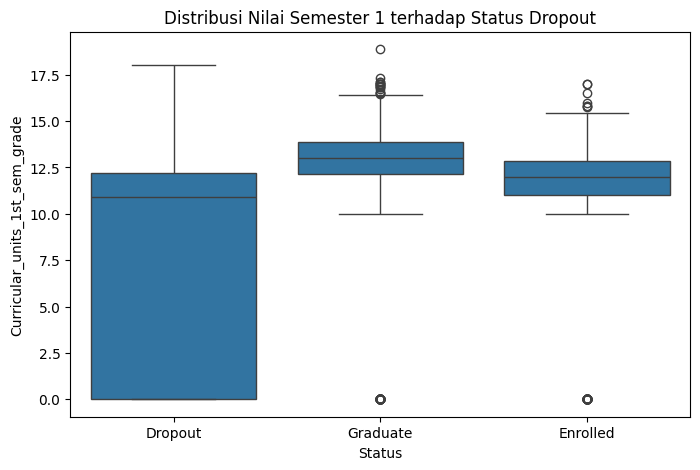

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Distribusi Nilai Semester 1 terhadap Status Dropout')
plt.show()

Insight:
- Mahasiswa dengan status dropout memiliki distribusi nilai semester 1 yang lebih rendah dan lebih menyebar, bahkan terdapat banyak nilai sangat rendah (mendekati 0).
- Sebaliknya, mahasiswa graduate memiliki median nilai yang lebih tinggi dan distribusi yang lebih stabil.
- Hal ini menunjukkan bahwa performa akademik sejak semester 1 sudah menjadi indikator awal yang kuat terhadap risiko dropout, bahkan sebelum pola berlanjut di semester berikutnya.

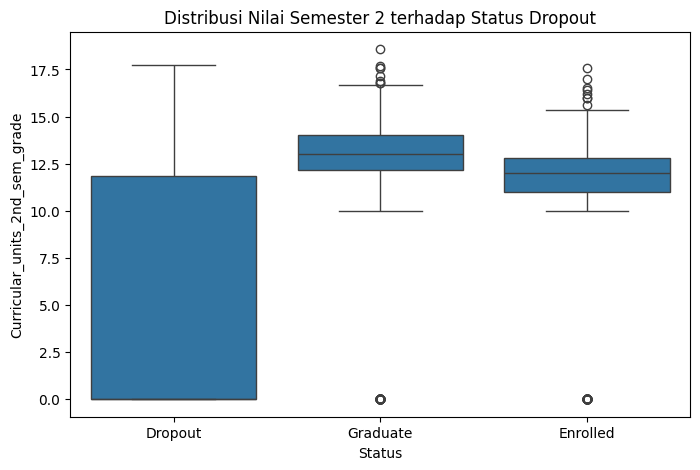

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df)
plt.title('Distribusi Nilai Semester 2 terhadap Status Dropout')    
plt.show()

Insight:
- Perbedaan distribusi nilai antara dropout dan graduate semakin jelas pada semester 2, di mana kelompok dropout tetap berada pada rentang nilai rendah secara konsisten.
- Hal ini menunjukkan bahwa penurunan performa akademik yang berlanjut (bukan hanya sekali) menjadi faktor kuat dalam meningkatkan risiko dropout.
- Nilai semester 2 memperkuat pola dari semester 1 dan dapat digunakan sebagai indikator konfirmasi risiko (secondary signal) dalam prediksi.

### Faktor Ekonomi

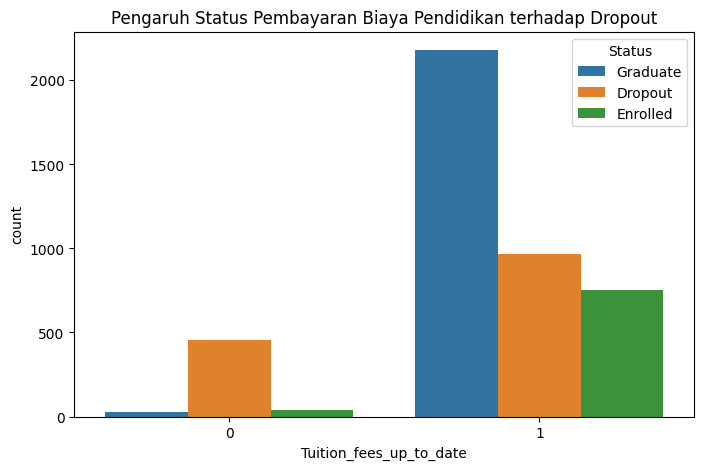

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Pengaruh Status Pembayaran Biaya Pendidikan terhadap Dropout')
plt.show()

Insight:
- Mahasiswa yang tidak membayar biaya pendidikan tepat waktu (status = 0) didominasi oleh kelompok dropout dibandingkan graduate.
- Sebaliknya, mahasiswa dengan status pembayaran lunas (status = 1) mayoritas berada pada kategori graduate.
- Hal ini menunjukkan bahwa stabilitas finansial memiliki hubungan kuat dengan keberlanjutan studi, dan dapat digunakan sebagai indikator penting dalam sistem deteksi dini.

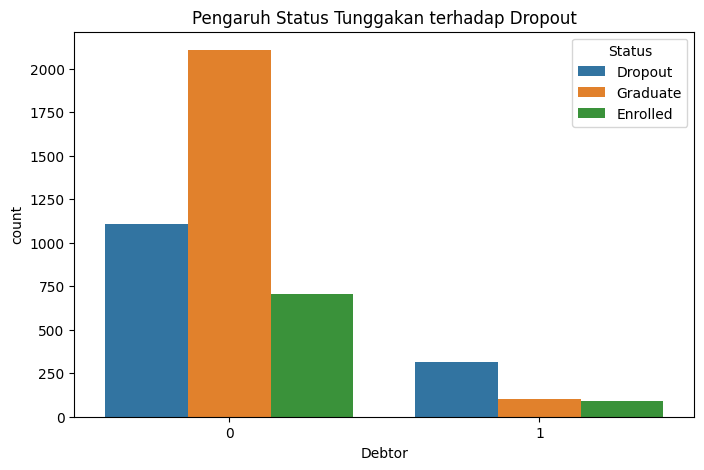

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Pengaruh Status Tunggakan terhadap Dropout')
plt.show()

Insight:
- Mahasiswa dengan status memiliki tunggakan (debtor = 1) memiliki proporsi dropout yang lebih tinggi dibandingkan yang tidak memiliki tunggakan.
- Sebaliknya, mahasiswa tanpa tunggakan lebih banyak berada pada kategori graduate.
- Hal ini menunjukkan bahwa masalah finansial yang berkelanjutan (bukan hanya telat bayar sekali) berkontribusi signifikan terhadap risiko dropout.

### Demografi

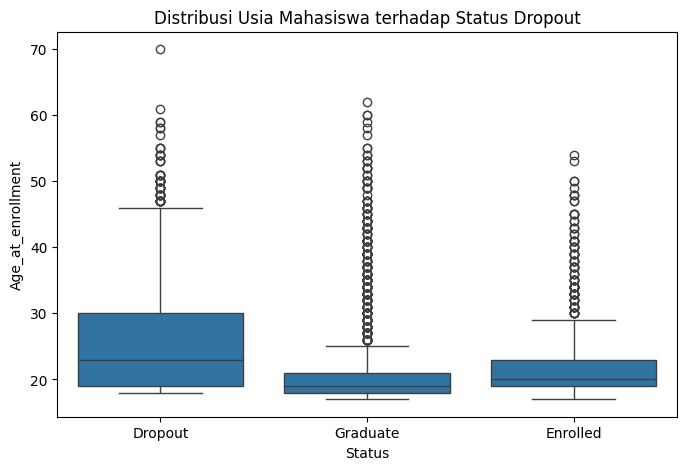

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Distribusi Usia Mahasiswa terhadap Status Dropout')
plt.show()

Insight:
- Mahasiswa dengan status dropout memiliki rentang usia yang lebih luas dan cenderung lebih tinggi dibandingkan graduate, meskipun terdapat overlap antar kelompok.
- Hal ini mengindikasikan bahwa usia bukan faktor utama, tetapi dapat menjadi faktor tambahan (supporting factor) dalam meningkatkan risiko dropout, terutama jika dikombinasikan dengan faktor lain seperti finansial dan akademik.

### Mata Kuliah yang Disetujui (Semester 1)

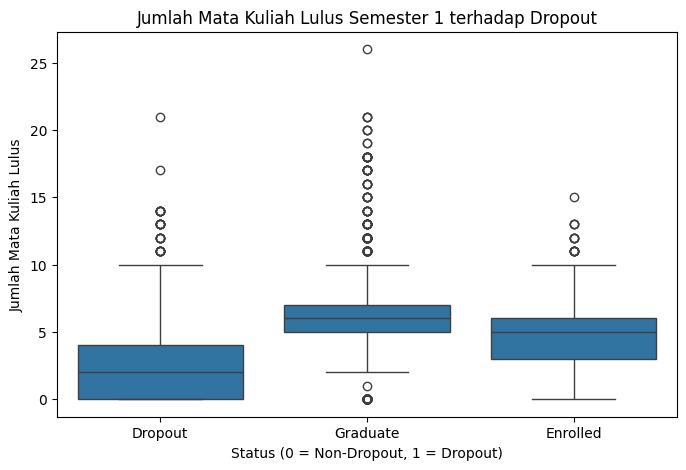

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Jumlah Mata Kuliah Lulus Semester 1 terhadap Dropout')
plt.xlabel('Status (0 = Non-Dropout, 1 = Dropout)')
plt.ylabel('Jumlah Mata Kuliah Lulus')
plt.show()

Insight:
- Mahasiswa dropout memiliki jumlah mata kuliah lulus yang jauh lebih rendah, bahkan banyak yang berada di angka sangat kecil.
- Sebaliknya, mahasiswa graduate memiliki jumlah mata kuliah lulus yang lebih tinggi dan konsisten.
- Sebaliknya, mahasiswa graduate memiliki jumlah mata kuliah lulus yang lebih tinggi dan konsisten.

### Beasiswa

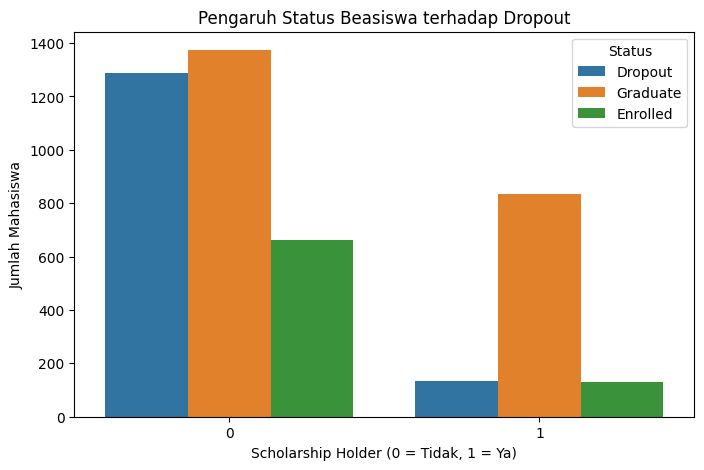

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Pengaruh Status Beasiswa terhadap Dropout')
plt.xlabel('Scholarship Holder (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(title='Status')
plt.show()

Insight:
- Mahasiswa penerima beasiswa (scholarship = 1) cenderung memiliki proporsi graduate yang lebih tinggi dibandingkan dropout.
- Hal ini menunjukkan bahwa dukungan finansial dapat meningkatkan keberlanjutan studi, baik secara langsung (mengurangi beban biaya) maupun tidak langsung (motivasi dan seleksi awal).

## Data Preparation / Preprocessing

In [45]:
df = df[df['Status'] != 'Enrolled']

In [46]:
df = df.dropna()

In [47]:
df = df.drop_duplicates()

In [48]:
df['Status'] = df['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

### Retrain Model

In [49]:
features = [
    'Age_at_enrollment',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Tuition_fees_up_to_date',
    'Debtor'
]

### Train Test Split

In [50]:
X = df[features]
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Modeling

In [51]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Save Model

In [52]:
import pickle

with open('model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [53]:
y_pred = model.predict(X_test)

## Evaluation

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8842975206611571


In [55]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       449
           1       0.89      0.80      0.84       277

    accuracy                           0.88       726
   macro avg       0.89      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



Model memiliki akurasi sekitar 88%, yang menunjukkan performa yang cukup baik dalam memprediksi status mahasiswa.
Model mampu mengidentifikasi sebagian besar mahasiswa non-dropout dengan baik, namun masih terdapat kesalahan dalam mendeteksi mahasiswa dropout.
Hal ini menunjukkan bahwa model masih memiliki keterbatasan dalam menangkap seluruh karakteristik mahasiswa berisiko tinggi.

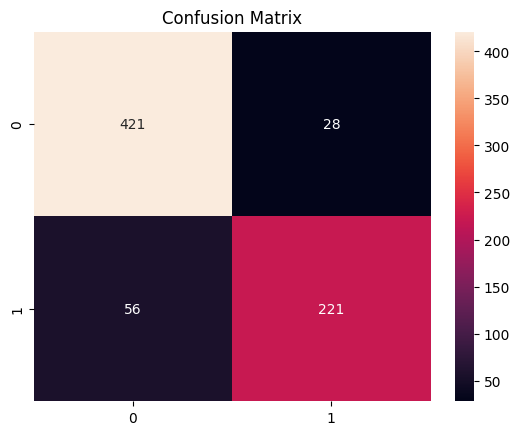

In [56]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

Insight:
- Hal ini menunjukkan bahwa dukungan finansial dapat meningkatkan keberlanjutan studi, baik secara langsung (mengurangi beban biaya) maupun tidak langsung (motivasi dan seleksi awal).
- Model mampu mengklasifikasikan sebagian besar mahasiswa dengan benar, namun masih terdapat kesalahan pada prediksi dropout (false negative) sebanyak 56 kasus.
- False negative ini menunjukkan bahwa terdapat mahasiswa yang sebenarnya berisiko dropout tetapi diprediksi tidak berisiko, yang berpotensi tidak mendapatkan intervensi dini.

## Feature Importance

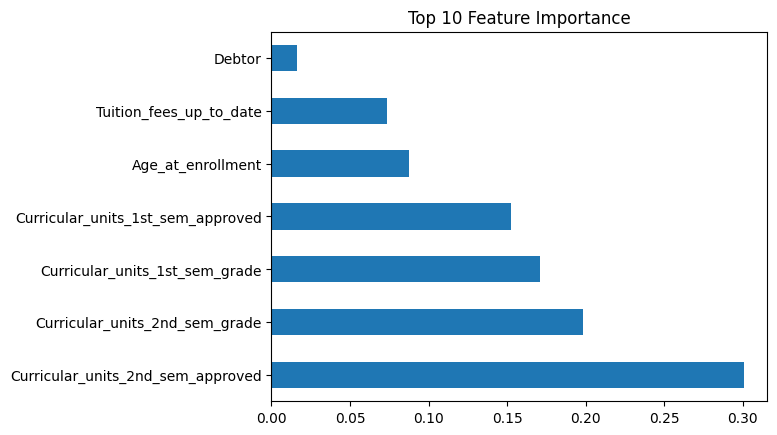

In [57]:
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.show()

In [58]:
df.to_csv('institusi_data_clean.csv', index=False)